# Retry Visualizer

Shows where the retry passes (A / B / C) resolved element-conservation failures
and the resulting mean molecular weight of the combined (original + retry) output.

**Inputs per composition:**
- `monitor_daniel.dat` — original run (determines which points were failing)
- `monitor_passA/B/C.dat` — per-pass results (optional; if absent, uses `monitor_retry.dat` only)
- `monitor_retry.dat` — final merged output used for m_u

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from pathlib import Path

CHEMISTRY_DIR = Path("input/chemistry")

# Discover: dirs with monitor_daniel.dat AND at least one retry output
COMPOSITIONS = sorted(
    d.name for d in CHEMISTRY_DIR.iterdir()
    if d.is_dir()
    and (d / "monitor_daniel.dat").exists()
    and (
        (d / "monitor_passA.dat").exists()
        or (d / "monitor_retry.dat").exists()
    )
)
print(f"Found {len(COMPOSITIONS)} compositions with retry data:", COMPOSITIONS)

Found 4 compositions with retry data: ['Bath(H4)_old', 'EL3_old', 'Krymka(LL3)_old', 'R3_old']


In [29]:
def parse_monitor(path):
    """Parse a FastChem monitor file (original or retry) into a DataFrame.

    Handles both monitor_daniel.dat (no grid_point prefix) and
    monitor_passA/B/C/retry.dat (grid_point as first column).
    ok/fail string columns are converted to bool (True = ok).
    """
    with open(path) as f:
        header_line = f.readline().lstrip("#").strip()

    raw_cols = [c.strip() for c in header_line.split("\t") if c.strip()]
    cols = [
        c.replace("(", "_").replace(")", "")
         .replace("-", "neg").replace("<", "").replace(">", "")
        for c in raw_cols
    ]

    df = pd.read_csv(
        path,
        sep=r"\s+",
        comment="#",
        header=None,
        names=cols,
    )

    ok_fail_cols = [c for c in ["converged", "elem_conserved"] if c in df.columns]
    ok_fail_cols += cols[11:]  # element columns
    for col in ok_fail_cols:
        if col in df.columns and df[col].dtype == object:
            df[col] = df[col].str.strip() == "ok"

    return df


FIXED_COLS = {
    "grid_point", "iterations", "chem_iter", "cond_iter",
    "converged", "elem_conserved", "p_bar", "T_K",
    "ntot_cmneg3", "n_tot_cmneg3", "n_g_cmneg3", "m_u",
}


def to_grid(df, value_col):
    """Pivot a monitor DataFrame column into a 2D array on the (T, P) grid.
    Returns (T_vals, P_vals, grid) where grid.shape == (n_T, n_P).
    """
    pivot = df.pivot_table(
        index="T_K", columns="p_bar", values=value_col, aggfunc="first"
    )
    return pivot.index.values, pivot.columns.values, pivot.values

In [30]:
def load_comp(comp_dir):
    """Return (orig_df, pass_dfs, retry_df) for one composition.
    pass_dfs is a dict with keys 'A', 'B', 'C' (value is None if file absent).
    """
    orig = parse_monitor(comp_dir / "monitor_daniel.dat")
    passes = {}
    for label, fname in [("A", "monitor_passA.dat"),
                          ("B", "monitor_passB.dat"),
                          ("C", "monitor_passC.dat")]:
        p = comp_dir / fname
        passes[label] = parse_monitor(p) if p.exists() else None

    retry_path = comp_dir / "monitor_retry.dat"
    retry = parse_monitor(retry_path) if retry_path.exists() else None
    return orig, passes, retry


# Status codes
# 0 = originally ok (not retried)
# 1 = fixed by pass A
# 2 = fixed by pass B
# 3 = fixed by pass C
# 4 = fixed by retry (pass breakdown unavailable)
# 5 = still failing after all retries

STATUS_COLORS = [
    "#aec7e8",  # 0: originally ok — light blue-gray
    "#2ca02c",  # 1: fixed by A — green
    "#ff7f0e",  # 2: fixed by B — orange
    "#9467bd",  # 3: fixed by C — purple
    "#17becf",  # 4: fixed (no pass breakdown) — teal
    "#d62728",  # 5: still failing — red
]
STATUS_LABELS = [
    "originally ok",
    "fixed by pass A",
    "fixed by pass B",
    "fixed by pass C",
    "fixed (no pass detail)",
    "still failing",
]
STATUS_CMAP = mcolors.ListedColormap(STATUS_COLORS)


def build_status(orig_df, passes, retry_df):
    """Assign a status code (0-5) to every row in orig_df."""
    # Start: originally ok=0, originally failing=5
    status = np.where(orig_df["elem_conserved"].values, 0, 5).copy()

    any_pass = any(v is not None for v in passes.values())

    if any_pass:
        # Build a grid_point → position mapping for orig_df
        gp_to_pos = {gp: pos for pos, gp in enumerate(orig_df["grid_point"].values)}

        for pass_label, code in [("A", 1), ("B", 2), ("C", 3)]:
            pdf = passes[pass_label]
            if pdf is None:
                continue
            fixed_gps = pdf.loc[pdf["elem_conserved"], "grid_point"].values
            for gp in fixed_gps:
                pos = gp_to_pos.get(int(gp))
                if pos is not None and status[pos] == 5:
                    status[pos] = code

    elif retry_df is not None:
        # No individual pass files — use monitor_retry.dat
        gp_to_pos = {gp: pos for pos, gp in enumerate(orig_df["grid_point"].values)}
        fixed_gps = retry_df.loc[retry_df["elem_conserved"], "grid_point"].values
        for gp in fixed_gps:
            pos = gp_to_pos.get(int(gp))
            if pos is not None and status[pos] == 5:
                status[pos] = 4  # fixed, no pass breakdown

    orig_df["retry_status"] = status
    return orig_df


def build_combined_mu(orig_df, retry_df):
    """Return orig_df with a 'm_u_combined' column, overriding retry rows."""
    orig_df["m_u_combined"] = orig_df["m_u"].copy()
    if retry_df is not None:
        retry_mu = retry_df.set_index("grid_point")["m_u"]
        orig_df["m_u_combined"] = orig_df["m_u_combined"].copy()
        mask = orig_df["grid_point"].isin(retry_mu.index)
        orig_df.loc[mask, "m_u_combined"] = orig_df.loc[mask, "grid_point"].map(retry_mu).values
    return orig_df


# Load everything
all_data = {}
for comp in COMPOSITIONS:
    comp_dir = CHEMISTRY_DIR / comp
    try:
        orig, passes, retry = load_comp(comp_dir)
        orig = build_status(orig, passes, retry)
        orig = build_combined_mu(orig, retry)
        all_data[comp] = orig
    except Exception as e:
        print(f"  Skipping {comp}: {e}")

print("Loaded:", list(all_data.keys()))

Loaded: ['Bath(H4)_old', 'EL3_old', 'Krymka(LL3)_old', 'R3_old']


## 1. Pass Resolution Map

Each grid point is colored by whether it was originally ok, fixed by pass A / B / C, or still failing.
When individual pass files are absent, "fixed (no pass detail)" is used.

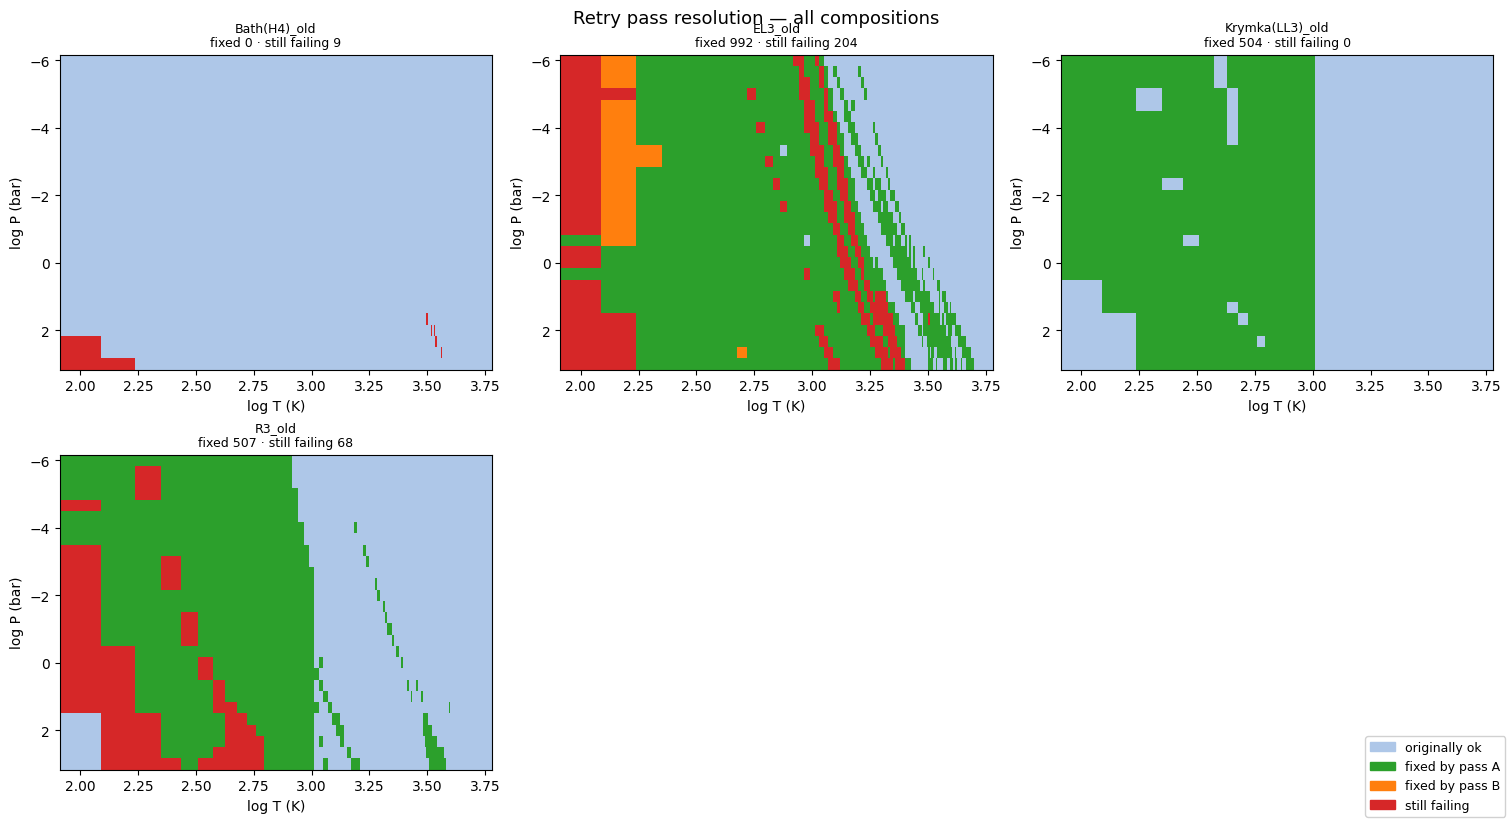

In [31]:
n = len(all_data)
ncols = min(3, n)
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows, ncols, figsize=(5 * ncols, 4 * nrows), constrained_layout=True
)
axes = np.array(axes).flatten()

for ax, (comp, df) in zip(axes, all_data.items()):
    T_vals, P_vals, grid = to_grid(df, "retry_status")
    ax.pcolormesh(
        np.log10(T_vals), np.log10(P_vals), grid.T,
        cmap=STATUS_CMAP, vmin=0, vmax=5, shading="nearest",
    )

    # Annotation: counts per category
    status_vals = df["retry_status"].values
    n_fail  = (status_vals == 5).sum()
    n_fixed = ((status_vals >= 1) & (status_vals <= 4)).sum()
    ax.set_title(
        f"{comp}\nfixed {n_fixed} · still failing {n_fail}",
        fontsize=9,
    )
    ax.set_xlabel("log T (K)")
    ax.set_ylabel("log P (bar)")
    ax.invert_yaxis()
    # ax.set_ylim(0, -6)
    # ax.set_xlim(np.log10(200), np.log10(2000))

for ax in axes[n:]:
    ax.set_visible(False)

# Only include legend entries for status codes actually present
present_codes = set()
for df in all_data.values():
    present_codes.update(df["retry_status"].unique())

patches = [
    Patch(color=STATUS_COLORS[i], label=STATUS_LABELS[i])
    for i in sorted(present_codes)
]
fig.legend(handles=patches, loc="lower right", fontsize=9, framealpha=0.9)
fig.suptitle("Retry pass resolution — all compositions", fontsize=13, y=1.01)
plt.show()

## 2. Combined Mean Molecular Weight

Mean molecular weight m(u) on the full T-P grid, using retry values where available
and original values elsewhere. NaN points (unconverged) shown in gray.

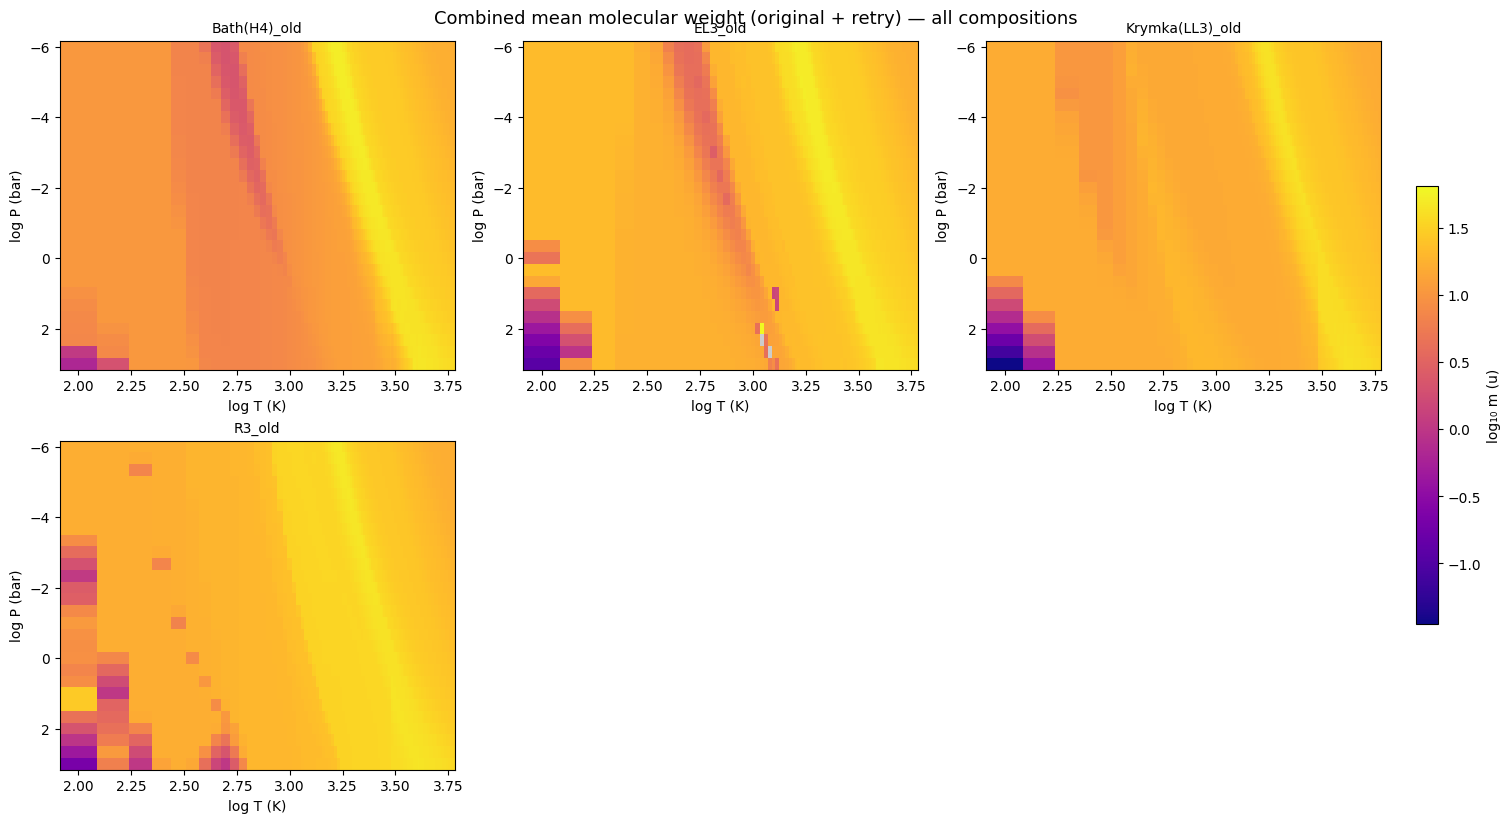

In [32]:
# Global color scale across all compositions (ignore NaN)
valid_mu = pd.concat(
    df["m_u_combined"].dropna() for df in all_data.values()
)
valid_mu = valid_mu[valid_mu > 0]
vmin_mu = np.log10(valid_mu.min())
vmax_mu = np.log10(valid_mu.max())

cmap_mu = plt.get_cmap("plasma").copy()
cmap_mu.set_bad(color="#cccccc")  # NaN → gray

n = len(all_data)
ncols = min(3, n)
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows, ncols, figsize=(5 * ncols, 4 * nrows), constrained_layout=True
)
axes = np.array(axes).flatten()

for ax, (comp, df) in zip(axes, all_data.items()):
    T_vals, P_vals, grid = to_grid(df, "m_u_combined")
    log_grid = np.where(grid > 0, np.log10(grid), np.nan)
    im = ax.pcolormesh(
        np.log10(T_vals), np.log10(P_vals), log_grid.T,
        cmap=cmap_mu, vmin=vmin_mu, vmax=vmax_mu, shading="nearest",
    )
    ax.set_title(comp, fontsize=10)
    ax.set_xlabel("log T (K)")
    ax.set_ylabel("log P (bar)")
    ax.invert_yaxis()
    # ax.set_ylim(0, -6)
    # ax.set_xlim(np.log10(200), np.log10(2000))

for ax in axes[n:]:
    ax.set_visible(False)

fig.colorbar(
    im, ax=axes[:n], label="log₁₀ m (u)",
    shrink=0.6, pad=0.02,
)
fig.suptitle("Combined mean molecular weight (original + retry) — all compositions",
             fontsize=13, y=1.01)
plt.show()

In [33]:
parse_monitor(CHEMISTRY_DIR / COMPOSITIONS[0] / "monitor_merged.dat").head()

,grid_point,iterations,chem_iter,cond_iter,converged,elem_conserved,p_bar,T_K,n_tot_cmneg3,n_g_cmneg3,...,Mn,N,Na,Ni,O,P,S,Si,Ti,Zn
0,0,1649,11764,4456,True,True,0.000001,100.0,1.526017e+16,7.242971e+13,...,True,True,True,True,True,True,True,True,True,True
1,1,1657,11774,4490,True,True,0.000002,100.0,3.288547e+16,1.560451e+14,...,True,True,True,True,True,True,True,True,True,True
2,2,1661,11777,4486,True,True,0.000005,100.0,7.085801e+16,3.361889e+14,...,True,True,True,True,True,True,True,True,True,True
3,3,1662,11784,4455,True,True,0.000010,100.0,1.526674e+17,7.242971e+14,...,True,True,True,True,True,True,True,True,True,True
4,4,1662,11797,4468,True,True,0.000022,100.0,3.289204e+17,1.560451e+15,...,True,True,True,True,True,True,True,True,True,True


In [34]:
all_merged = {}
for comp in COMPOSITIONS:
    comp_dir = CHEMISTRY_DIR / comp
    try:
        all_merged[comp] = parse_monitor(comp_dir / "monitor_merged.dat")
    except Exception as e:
        print(f"  Skipping {comp}: {e}")

print("Loaded:", list(all_merged.keys()))

Loaded: ['Bath(H4)_old', 'EL3_old', 'Krymka(LL3)_old', 'R3_old']


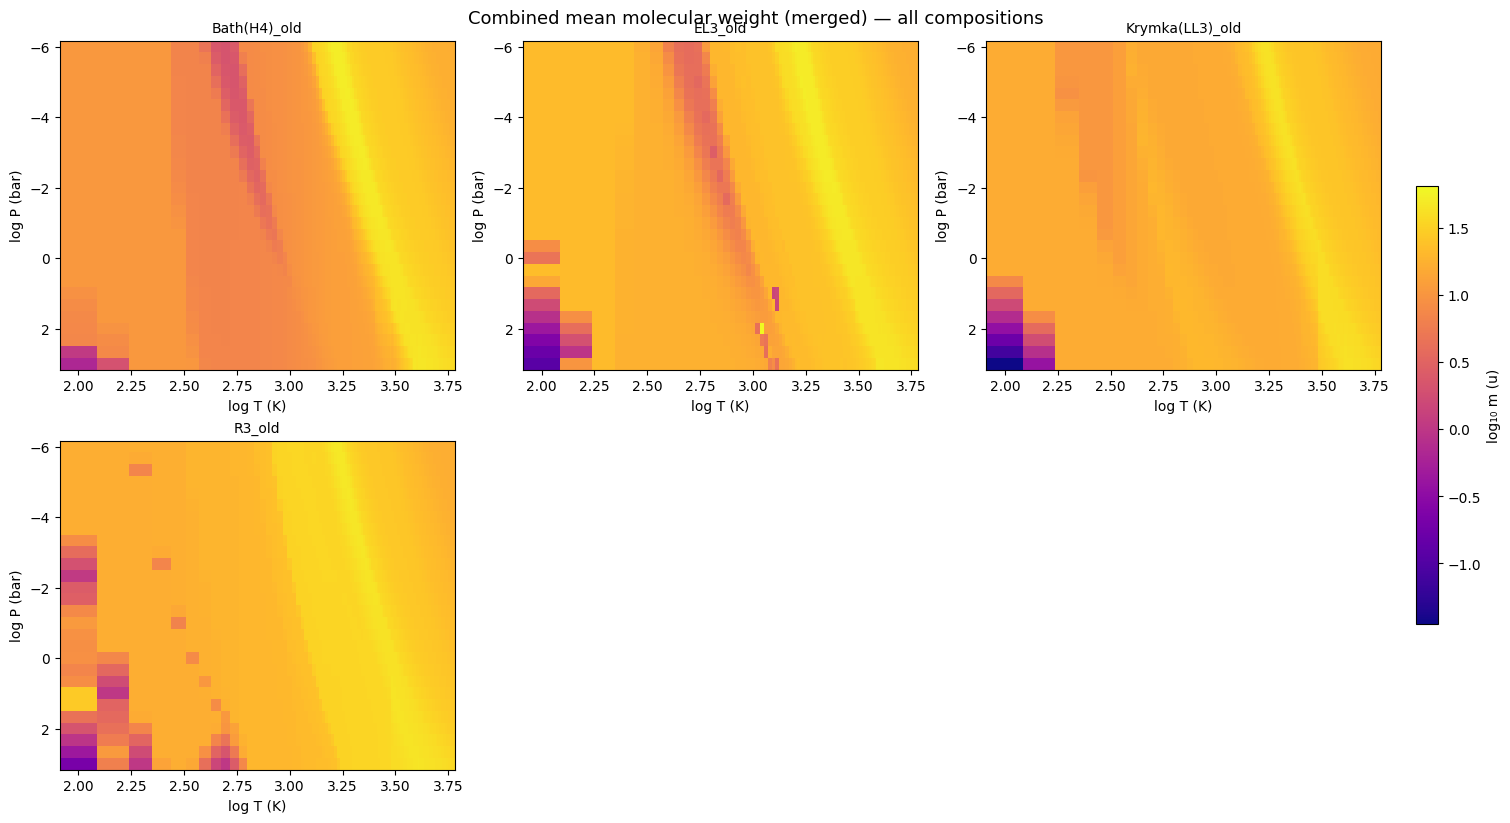

In [35]:
# Global color scale across all compositions (ignore NaN)
valid_mu = pd.concat(
    df["m_u"].dropna() for df in all_merged.values()
)
valid_mu = valid_mu[valid_mu > 0]
vmin_mu = np.log10(valid_mu.min())
vmax_mu = np.log10(valid_mu.max())

cmap_mu = plt.get_cmap("plasma").copy()
cmap_mu.set_bad(color="#cccccc")  # NaN → gray

n = len(all_data)
ncols = min(3, n)
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows, ncols, figsize=(5 * ncols, 4 * nrows), constrained_layout=True
)
axes = np.array(axes).flatten()

for ax, (comp, df) in zip(axes, all_merged.items()):
    T_vals, P_vals, grid = to_grid(df, "m_u")
    log_grid = np.where(grid > 0, np.log10(grid), np.nan)
    im = ax.pcolormesh(
        np.log10(T_vals), np.log10(P_vals), log_grid.T,
        cmap=cmap_mu, vmin=vmin_mu, vmax=vmax_mu, shading="nearest",
    )
    ax.set_title(comp, fontsize=10)
    ax.set_xlabel("log T (K)")
    ax.set_ylabel("log P (bar)")
    ax.invert_yaxis()
    # ax.set_ylim(0, -6)
    # ax.set_xlim(np.log10(200), np.log10(2000))

for ax in axes[n:]:
    ax.set_visible(False)

fig.colorbar(
    im, ax=axes[:n], label="log₁₀ m (u)",
    shrink=0.6, pad=0.02,
)
fig.suptitle("Combined mean molecular weight (merged) — all compositions",
             fontsize=13, y=1.01)
plt.show()

In [36]:
EL3_merged = all_merged.get("EL3_old")

In [37]:
EL3_merged[EL3_merged["m_u"].isna()]

,grid_point,iterations,chem_iter,cond_iter,converged,elem_conserved,p_bar,T_K,n_tot_cmneg3,n_g_cmneg3,...,Mn,N,Na,Ni,O,P,S,Si,Ti,Zn


In [38]:
EL3_original = all_data.get("EL3_old")

In [39]:
EL3_original[EL3_original["m_u"].isna()]

,grid_point,iterations,chem_iter,cond_iter,converged,elem_conserved,p_bar,T_K,n_tot_cmneg3,n_g_cmneg3,...,Na,Ni,O,P,S,Si,Ti,Zn,retry_status,m_u_combined


In [40]:
#replace rows with NaN in merged with same rows from original
EL3_merged

,grid_point,iterations,chem_iter,cond_iter,converged,elem_conserved,p_bar,T_K,n_tot_cmneg3,n_g_cmneg3,...,Mn,N,Na,Ni,O,P,S,Si,Ti,Zn
0,0,1042,6040,4514,True,False,0.000001,100.0,5.170429e+16,7.242971e+13,...,True,False,True,True,True,False,True,True,True,True
1,1,1042,6036,4507,True,False,0.000002,100.0,1.113935e+17,1.560451e+14,...,True,False,True,True,True,False,True,True,True,True
2,2,1042,6038,4503,True,False,0.000005,100.0,2.399901e+17,3.361889e+14,...,True,False,True,True,True,False,True,True,True,True
3,3,1042,6048,4502,True,False,0.000010,100.0,5.170429e+17,7.242971e+14,...,True,False,True,True,True,False,True,True,True,True
4,4,1042,6052,4524,True,False,0.000022,100.0,1.113935e+18,1.560451e+15,...,True,False,True,True,True,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3327,3327,0,12,0,True,True,46.415890,6000.0,6.964291e+19,5.603149e+19,...,True,True,True,True,True,True,True,True,True,True
3328,3328,0,12,0,True,True,100.000000,6000.0,1.559977e+20,1.207162e+20,...,True,True,True,True,True,True,True,True,True,True
3329,3329,0,12,0,True,True,215.443500,6000.0,3.530247e+20,2.600752e+20,...,True,True,True,True,True,True,True,True,True,True
3330,3330,0,13,0,True,True,464.158900,6000.0,8.057601e+20,5.603149e+20,...,True,True,True,True,True,True,True,True,True,True
